In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [2]:
SEED = 42

LOOKBACK = 60
HORIZON = 5

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 7

LEARNING_RATE = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [3]:
data = pd.read_csv(
    "../data/fred_economic_data.csv",
    index_col=0,
    parse_dates=True,
)

data = data.sort_index()

print(data.shape)
print(data.index.min(), "->", data.index.max())

data.head()

(1585, 6)
2018-01-01 00:00:00 -> 2023-12-29 00:00:00


,SP500,DGS10,UNRATE,CPIAUCSL,DCOILWTICO,NASDAQCOM
DATE,,,,,,
2018-01-01,NaN,NaN,4.0,248.859,NaN,NaN
2018-01-02,2695.81,2.46,4.0,248.859,60.37,7006.90
2018-01-03,2713.06,2.44,4.0,248.859,61.61,7065.53
2018-01-04,2723.99,2.46,4.0,248.859,61.98,7077.91
2018-01-05,2743.15,2.47,4.0,248.859,61.49,7136.56


In [4]:
def create_features(data):
    df = data.copy()

    # Returns
    for col in df.columns:
        df[f"{col}_return"] = df[col].pct_change(
            fill_method=None
        )

    # Moving averages as distance from current price
    for window in [5, 20, 50]:
        ma = df["SP500"].rolling(window).mean()

        df[f"SP500_MA{window}_ratio"] = (
            df["SP500"] / ma - 1
        )

    # Volatility
    df["SP500_Vol_5"] = (
        df["SP500_return"]
        .rolling(5)
        .std()
    )

    df["SP500_Vol_20"] = (
        df["SP500_return"]
        .rolling(20)
        .std()
    )

    # Momentum
    for window in [5, 20, 60]:
        df[f"SP500_Momentum_{window}"] = (
            df["SP500"]
            / df["SP500"].shift(window)
            - 1
        )

        df[f"NASDAQ_Momentum_{window}"] = (
            df["NASDAQCOM"]
            / df["NASDAQCOM"].shift(window)
            - 1
        )

    # Changes in macro variables
    df["Yield_Change_5"] = (
        df["DGS10"].pct_change(
            periods=5,
            fill_method=None,
        )
    )

    df["Oil_Change_5"] = (
        df["DCOILWTICO"].pct_change(
            periods=5,
            fill_method=None,
        )
    )

    df = df.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    df = df.dropna()

    return df


df = create_features(data)

print("Shape:", df.shape)
print("Missing:", df.isna().sum().sum())

df.head()

Shape: (1524, 25)
Missing: 0


,SP500,DGS10,UNRATE,CPIAUCSL,DCOILWTICO,NASDAQCOM,SP500_return,DGS10_return,UNRATE_return,CPIAUCSL_return,...,SP500_Vol_5,SP500_Vol_20,SP500_Momentum_5,NASDAQ_Momentum_5,SP500_Momentum_20,NASDAQ_Momentum_20,SP500_Momentum_60,NASDAQ_Momentum_60,Yield_Change_5,Oil_Change_5
DATE,,,,,,,,,,,,,,,,,,,,,
2018-03-27,2612.62,2.78,4.0,249.577,65.21,7008.81,-0.017276,-0.024561,0.0,0.000000,...,0.021342,0.012688,-0.038396,-0.048272,-0.047976,-0.043864,-0.030859,0.000273,-0.038062,0.029036
2018-03-28,2605.00,2.77,4.0,249.577,64.30,6949.23,-0.002917,-0.003597,0.0,0.000000,...,0.021275,0.012523,-0.039429,-0.053920,-0.040102,-0.044518,-0.039830,-0.016460,-0.041522,-0.012289
2018-03-29,2640.87,2.74,4.0,249.577,64.87,7063.44,0.013770,-0.010830,0.0,0.000000,...,0.020455,0.012694,-0.001067,-0.014406,-0.013743,-0.016311,-0.030514,-0.002044,-0.031802,0.009650
2018-03-30,2640.87,2.74,4.0,249.577,64.87,7063.44,0.000000,0.000000,0.0,0.000000,...,0.016942,0.012625,0.020326,0.010121,-0.018720,-0.026789,-0.037286,-0.010246,-0.028369,-0.014134
2018-04-01,4769.83,3.88,4.0,250.227,71.89,15011.35,0.806159,0.416058,0.0,0.002604,...,0.361411,0.181016,0.794147,1.078979,0.753008,1.047738,0.735929,1.097322,0.361404,0.097725


In [5]:
train_end = int(
    len(df) * TRAIN_RATIO
)

val_end = int(
    len(df) * (TRAIN_RATIO + VAL_RATIO)
)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(
    "Train:",
    train_df.index.min(),
    "->",
    train_df.index.max(),
)

print(
    "Validation:",
    val_df.index.min(),
    "->",
    val_df.index.max(),
)

print(
    "Test:",
    test_df.index.min(),
    "->",
    test_df.index.max(),
)

Train: 2018-03-27 00:00:00 -> 2022-04-06 00:00:00
Validation: 2022-04-07 00:00:00 -> 2023-02-16 00:00:00
Test: 2023-02-17 00:00:00 -> 2023-12-29 00:00:00


In [6]:
EXCLUDED_COLUMNS = [
    "SP500",
    "DGS10",
    "UNRATE",
    "CPIAUCSL",
    "DCOILWTICO",
    "NASDAQCOM",
]

feature_columns = [
    col
    for col in df.columns
    if col not in EXCLUDED_COLUMNS
]

print("Number of features:", len(feature_columns))

feature_columns

Number of features: 19


['SP500_return',
 'DGS10_return',
 'UNRATE_return',
 'CPIAUCSL_return',
 'DCOILWTICO_return',
 'NASDAQCOM_return',
 'SP500_MA5_ratio',
 'SP500_MA20_ratio',
 'SP500_MA50_ratio',
 'SP500_Vol_5',
 'SP500_Vol_20',
 'SP500_Momentum_5',
 'NASDAQ_Momentum_5',
 'SP500_Momentum_20',
 'NASDAQ_Momentum_20',
 'SP500_Momentum_60',
 'NASDAQ_Momentum_60',
 'Yield_Change_5',
 'Oil_Change_5']

In [7]:
feature_scaler = StandardScaler()

feature_scaler.fit(
    train_df[feature_columns]
)

all_features = feature_scaler.transform(
    df[feature_columns]
)

all_features.shape

(1524, 19)

In [8]:
sp500_prices = df["SP500"].values

sp500_returns = (
    df["SP500"]
    .pct_change(fill_method=None)
    .values
)

print(sp500_prices.shape)
print(sp500_returns.shape)

(1524,)
(1524,)


In [9]:
def create_sequences(
    features,
    returns,
    prices,
    lookback,
    horizon,
):
    X = []
    y = []

    last_prices = []
    target_prices = []
    target_indices = []

    for i in range(
        lookback,
        len(features) - horizon + 1,
    ):
        X.append(
            features[i - lookback:i]
        )

        y.append(
            returns[i:i + horizon]
        )

        last_prices.append(
            prices[i - 1]
        )

        target_prices.append(
            prices[i:i + horizon]
        )

        target_indices.append(i)

    return (
        np.array(X),
        np.array(y),
        np.array(last_prices),
        np.array(target_prices),
        np.array(target_indices),
    )


(
    X,
    y,
    last_prices,
    target_prices,
    target_indices,
) = create_sequences(
    all_features,
    sp500_returns,
    sp500_prices,
    LOOKBACK,
    HORIZON,
)

print("X:", X.shape)
print("y:", y.shape)

X: (1460, 60, 19)
y: (1460, 5)


In [11]:
train_mask = (
    target_indices + HORIZON
    <= train_end
)

val_mask = (
    (target_indices >= train_end)
    &
    (target_indices + HORIZON <= val_end)
)

test_mask = (
    target_indices >= val_end
)


X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

last_price_test = last_prices[test_mask]
target_price_test = target_prices[test_mask]


print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1002, 60, 19) (1002, 5)
Val: (225, 60, 19) (225, 5)
Test: (225, 60, 19) (225, 5)


In [12]:
target_scaler = StandardScaler()

target_scaler.fit(
    y_train.reshape(-1, 1)
)


def scale_targets(y):
    shape = y.shape

    scaled = target_scaler.transform(
        y.reshape(-1, 1)
    )

    return scaled.reshape(shape)


y_train_scaled = scale_targets(y_train)
y_val_scaled = scale_targets(y_val)
y_test_scaled = scale_targets(y_test)


print(y_train_scaled.shape)

(1002, 5)


In [13]:
def make_loader(
    X,
    y,
    shuffle,
):
    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor,
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )


train_loader = make_loader(
    X_train,
    y_train_scaled,
    True,
)

val_loader = make_loader(
    X_val,
    y_val_scaled,
    False,
)

In [14]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
        horizon=5,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(
            hidden_size
        )

        self.head = nn.Sequential(
            nn.Linear(
                hidden_size,
                64,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                64,
                horizon,
            ),
        )

    def forward(self, x):
        output, _ = self.lstm(x)

        x = output[:, -1, :]
        x = self.norm(x)

        return self.head(x)

In [15]:
class TransformerModel(nn.Module):

    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2,
        horizon=5,
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model,
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                LOOKBACK,
                d_model,
            )
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.norm = nn.LayerNorm(
            d_model
        )

        self.head = nn.Sequential(
            nn.Linear(
                d_model,
                64,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                64,
                horizon,
            ),
        )

    def forward(self, x):
        x = self.input_projection(x)

        x = (
            x
            + self.position_embedding[
                :, :x.size(1)
            ]
        )

        x = self.encoder(x)

        x = x[:, -1, :]
        x = self.norm(x)

        return self.head(x)

In [16]:
def train_model(
    model,
    train_loader,
    val_loader,
    name,
):
    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4,
    )

    best_loss = float("inf")
    best_state = None

    patience_counter = 0

    history = {
        "train": [],
        "val": [],
    }

    for epoch in range(
        1,
        EPOCHS + 1,
    ):
        model.train()

        train_loss = 0.0
        train_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch,
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            batch_size = X_batch.size(0)

            train_loss += (
                loss.item()
                * batch_size
            )

            train_samples += batch_size

        train_loss /= train_samples

        model.eval()

        val_loss = 0.0
        val_samples = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(
                    X_batch
                )

                loss = criterion(
                    predictions,
                    y_batch,
                )

                batch_size = X_batch.size(0)

                val_loss += (
                    loss.item()
                    * batch_size
                )

                val_samples += batch_size

        val_loss /= val_samples

        history["train"].append(
            train_loss
        )

        history["val"].append(
            val_loss
        )

        print(
            f"{name} | "
            f"Epoch {epoch:02d} | "
            f"Train {train_loss:.4f} | "
            f"Val {val_loss:.4f}"
        )

        if val_loss < best_loss:
            best_loss = val_loss

            best_state = {
                key: value.cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            patience_counter = 0

        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}"
            )
            break

    model.load_state_dict(
        best_state
    )

    model = model.to(device)

    return model, history, best_loss

In [17]:
input_size = X_train.shape[2]

lstm = LSTMModel(
    input_size=input_size,
    horizon=HORIZON,
)

lstm, lstm_history, lstm_val_loss = train_model(
    lstm,
    train_loader,
    val_loader,
    "LSTM",
)

print(
    "Best LSTM val loss:",
    lstm_val_loss,
)

LSTM | Epoch 01 | Train 1.0153 | Val 0.2905
LSTM | Epoch 02 | Train 0.9882 | Val 0.2895
LSTM | Epoch 03 | Train 0.9754 | Val 0.2818
LSTM | Epoch 04 | Train 0.9548 | Val 0.2791
LSTM | Epoch 05 | Train 0.9556 | Val 0.2777
LSTM | Epoch 06 | Train 0.9503 | Val 0.2782
LSTM | Epoch 07 | Train 0.9483 | Val 0.2770
LSTM | Epoch 08 | Train 0.9462 | Val 0.2777
LSTM | Epoch 09 | Train 0.9454 | Val 0.2814
LSTM | Epoch 10 | Train 0.9424 | Val 0.2772
LSTM | Epoch 11 | Train 0.9430 | Val 0.2729
LSTM | Epoch 12 | Train 0.9447 | Val 0.2887
LSTM | Epoch 13 | Train 0.9424 | Val 0.2796
LSTM | Epoch 14 | Train 0.9346 | Val 0.3083
LSTM | Epoch 15 | Train 0.9295 | Val 0.2768
LSTM | Epoch 16 | Train 0.9184 | Val 0.2801
LSTM | Epoch 17 | Train 0.8982 | Val 0.2753
LSTM | Epoch 18 | Train 0.8745 | Val 0.2757
Early stopping at epoch 18
Best LSTM val loss: 0.2728547198697925


In [18]:
transformer = TransformerModel(
    input_size=input_size,
    horizon=HORIZON,
)

transformer, transformer_history, transformer_val_loss = train_model(
    transformer,
    train_loader,
    val_loader,
    "Transformer",
)

print(
    "Best Transformer val loss:",
    transformer_val_loss,
)

c:\Users\Али Айнур\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Transformer | Epoch 01 | Train 1.0167 | Val 0.2999
Transformer | Epoch 02 | Train 0.9823 | Val 0.2790
Transformer | Epoch 03 | Train 0.9659 | Val 0.2774
Transformer | Epoch 04 | Train 0.9542 | Val 0.2801
Transformer | Epoch 05 | Train 0.9506 | Val 0.2806
Transformer | Epoch 06 | Train 0.9518 | Val 0.2771
Transformer | Epoch 07 | Train 0.9495 | Val 0.2774
Transformer | Epoch 08 | Train 0.9449 | Val 0.2812
Transformer | Epoch 09 | Train 0.9481 | Val 0.2771
Transformer | Epoch 10 | Train 0.9454 | Val 0.2756
Transformer | Epoch 11 | Train 0.9377 | Val 0.2813
Transformer | Epoch 12 | Train 0.9379 | Val 0.2744
Transformer | Epoch 13 | Train 0.9402 | Val 0.2916
Transformer | Epoch 14 | Train 0.9290 | Val 0.2741
Transformer | Epoch 15 | Train 0.9253 | Val 0.2743
Transformer | Epoch 16 | Train 0.9213 | Val 0.2750
Transformer | Epoch 17 | Train 0.9367 | Val 0.2755
Transformer | Epoch 18 | Train 0.9214 | Val 0.2848
Transformer | Epoch 19 | Train 0.9132 | Val 0.2753
Transformer | Epoch 20 | Train 

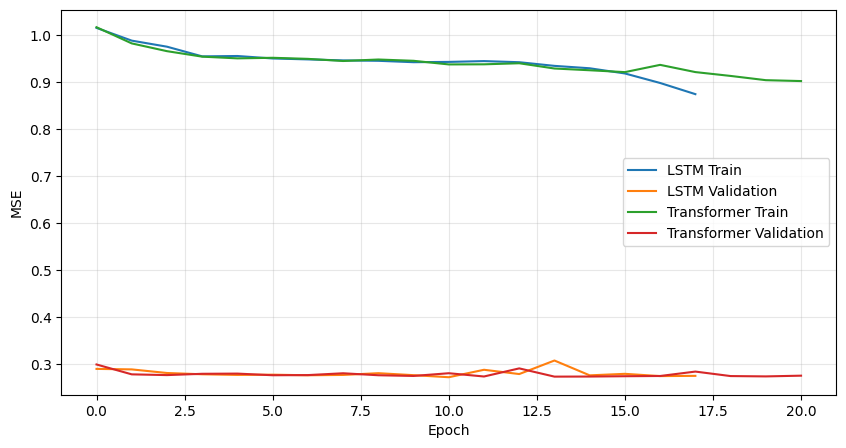

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history["train"],
    label="LSTM Train",
)

plt.plot(
    lstm_history["val"],
    label="LSTM Validation",
)

plt.plot(
    transformer_history["train"],
    label="Transformer Train",
)

plt.plot(
    transformer_history["val"],
    label="Transformer Validation",
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
def predict(model, X):
    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
    ).to(device)

    with torch.no_grad():
        predictions = model(
            X_tensor
        )

    predictions = (
        predictions
        .cpu()
        .numpy()
    )

    shape = predictions.shape

    predictions = (
        target_scaler
        .inverse_transform(
            predictions.reshape(-1, 1)
        )
        .reshape(shape)
    )

    return predictions

In [21]:
def returns_to_prices(
    last_prices,
    predicted_returns,
):
    result = []

    for last_price, returns in zip(
        last_prices,
        predicted_returns,
    ):
        prices = []

        current_price = last_price

        for daily_return in returns:
            current_price = (
                current_price
                * (1 + daily_return)
            )

            prices.append(
                current_price
            )

        result.append(prices)

    return np.array(result)

In [22]:
lstm_returns = predict(
    lstm,
    X_test,
)

transformer_returns = predict(
    transformer,
    X_test,
)


lstm_prices = returns_to_prices(
    last_price_test,
    lstm_returns,
)

transformer_prices = returns_to_prices(
    last_price_test,
    transformer_returns,
)

In [23]:
naive_prices = np.repeat(
    last_price_test[:, None],
    HORIZON,
    axis=1,
)

naive_prices.shape

(225, 5)

In [24]:
def calculate_metrics(
    actual,
    predicted,
):
    actual_flat = actual.reshape(-1)
    predicted_flat = predicted.reshape(-1)

    mae = mean_absolute_error(
        actual_flat,
        predicted_flat,
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_flat,
            predicted_flat,
        )
    )

    mape = np.mean(
        np.abs(
            (
                actual_flat
                - predicted_flat
            )
            / actual_flat
        )
    ) * 100

    r2 = r2_score(
        actual_flat,
        predicted_flat,
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
    }


naive_metrics = calculate_metrics(
    target_price_test,
    naive_prices,
)

lstm_metrics = calculate_metrics(
    target_price_test,
    lstm_prices,
)

transformer_metrics = calculate_metrics(
    target_price_test,
    transformer_prices,
)

In [25]:
results = pd.DataFrame(
    {
        "Naive": naive_metrics,
        "LSTM": lstm_metrics,
        "Transformer": transformer_metrics,
    }
).T

results

,MAE,RMSE,MAPE,R2
Naive,58.149769,105.729709,1.339056,0.767566
LSTM,55.439334,90.310140,1.280140,0.830418
Transformer,53.260809,92.970491,1.226587,0.820280


In [26]:
horizon_results = []

for day in range(HORIZON):

    for name, predictions in [
        ("Naive", naive_prices),
        ("LSTM", lstm_prices),
        ("Transformer", transformer_prices),
    ]:
        metrics = calculate_metrics(
            target_price_test[:, day],
            predictions[:, day],
        )

        horizon_results.append(
            {
                "Model": name,
                "Day": day + 1,
                **metrics,
            }
        )


horizon_results = pd.DataFrame(
    horizon_results
)

horizon_results

,Model,Day,MAE,RMSE,MAPE,R2
0,Naive,1,38.120444,88.524535,0.876438,0.833055
1,LSTM,1,40.079250,77.350113,0.927432,0.872542
2,Transformer,1,35.072682,75.411249,0.803831,0.878851
3,Naive,2,51.124622,99.420108,1.179012,0.792255
4,LSTM,2,49.515942,86.762817,1.147868,0.841784
5,Transformer,2,46.110193,86.187587,1.061331,0.843875
6,Naive,3,59.899067,106.656579,1.380195,0.764117
7,LSTM,3,56.311388,90.637820,1.303047,0.829650
8,Transformer,3,55.381404,93.947591,1.276553,0.816982
9,Naive,4,67.693244,113.963932,1.559326,0.733016


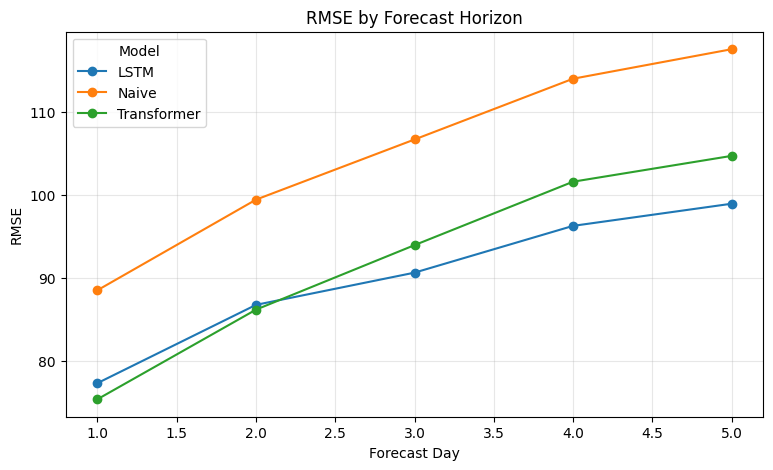

In [27]:
pivot_rmse = horizon_results.pivot(
    index="Day",
    columns="Model",
    values="RMSE",
)

pivot_rmse.plot(
    marker="o",
    figsize=(9, 5),
)

plt.xlabel("Forecast Day")
plt.ylabel("RMSE")
plt.title("RMSE by Forecast Horizon")
plt.grid(alpha=0.3)
plt.show()

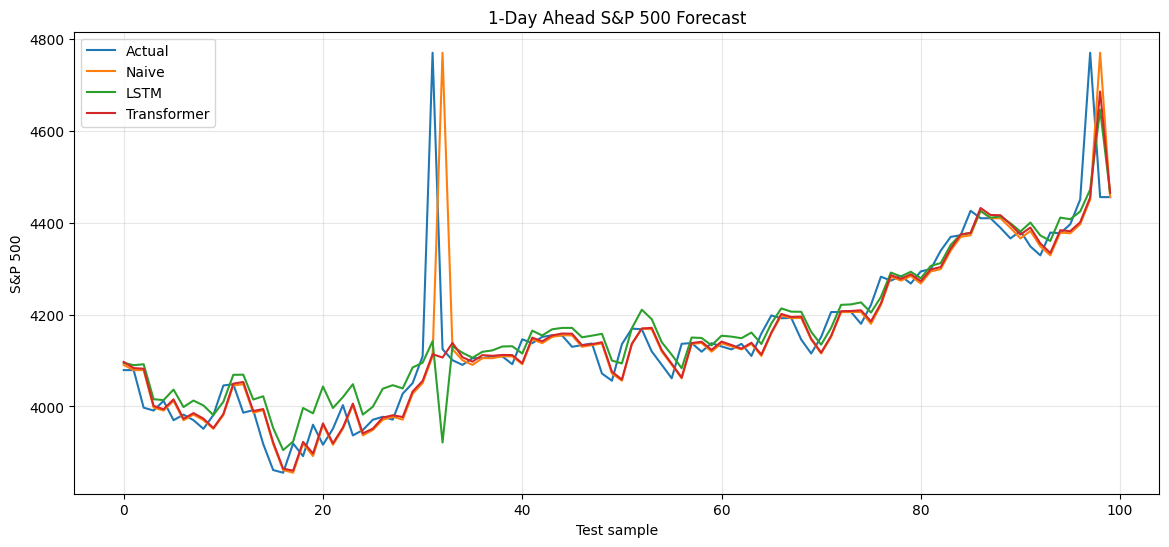

In [28]:
sample_count = min(
    100,
    len(target_price_test),
)

plt.figure(figsize=(14, 6))

plt.plot(
    target_price_test[:sample_count, 0],
    label="Actual",
)

plt.plot(
    naive_prices[:sample_count, 0],
    label="Naive",
)

plt.plot(
    lstm_prices[:sample_count, 0],
    label="LSTM",
)

plt.plot(
    transformer_prices[:sample_count, 0],
    label="Transformer",
)

plt.title(
    "1-Day Ahead S&P 500 Forecast"
)

plt.xlabel("Test sample")
plt.ylabel("S&P 500")
plt.legend()
plt.grid(alpha=0.3)
plt.show()